# Análise exploratória — Comportamento de estoques (Saltim)

Notebook para inspecionar o dataset sintético `estoques.csv` (2023-01-01 a 2026-05-19).

**Fontes:**
- `estoques.csv` — snapshots diários de saldo por ingrediente (20:00)
- `ingredientes.csv` e `categorias.csv` — metadados de item
- `resumo_diario_estoques.csv` e `resumo_mensal_estoques.csv` — indicadores agregados
- `vendas.csv`, `receitas.csv`, `receitas_ingredientes.csv` — consumo derivado por BOM
- `produtos_indisponiveis.csv` — períodos de indisponibilidade de produtos
- `pedidos.csv` — pedidos efetivados a fornecedores

## 1. Setup e carga dos dados

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

_HERE = Path.cwd().resolve()
_CANDIDATES = [
    _HERE,
    _HERE.parent,
    _HERE / "data",
    _HERE.parent / "data",
]
DATA_DIR = next((p for p in _CANDIDATES if (p / "estoques.csv").exists()), None)
if DATA_DIR is None:
    raise FileNotFoundError(
        "Não foi possível localizar 'estoques.csv'. "
        "Confirme que o notebook está em 'data/notebooks/' e que os CSVs estão em 'data/'."
    )

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams.update({
    "figure.figsize": (12, 5),
    "axes.titlesize": 13,
    "axes.labelsize": 11,
})

MESES_PT = {
    1: "Jan", 2: "Fev", 3: "Mar", 4: "Abr", 5: "Mai", 6: "Jun",
    7: "Jul", 8: "Ago", 9: "Set", 10: "Out", 11: "Nov", 12: "Dez",
}
DIAS_PT = ["Seg", "Ter", "Qua", "Qui", "Sex", "Sáb", "Dom"]

estoques = pd.read_csv(DATA_DIR / "estoques.csv", parse_dates=["date_time"])
ingredientes = pd.read_csv(DATA_DIR / "ingredientes.csv")
categorias = pd.read_csv(DATA_DIR / "categorias.csv")
resumo_diario = pd.read_csv(DATA_DIR / "resumo_diario_estoques.csv", parse_dates=["date"])
resumo_mensal = pd.read_csv(DATA_DIR / "resumo_mensal_estoques.csv")
vendas = pd.read_csv(DATA_DIR / "vendas.csv", parse_dates=["date_time"])
receitas = pd.read_csv(DATA_DIR / "receitas.csv")
ri = pd.read_csv(DATA_DIR / "receitas_ingredientes.csv")
indisp = pd.read_csv(DATA_DIR / "produtos_indisponiveis.csv", parse_dates=["data_inicio", "data_fim"])
pedidos_path = DATA_DIR / "pedidos.csv"
pedidos = (
    pd.read_csv(pedidos_path, parse_dates=["data_pedido", "data_prevista"])
    if pedidos_path.exists() else pd.DataFrame()
)

ingredientes = ingredientes.rename(columns={"id": "ingredient_id", "name": "ingrediente"})
categorias = categorias.rename(columns={"id": "category_id", "name": "categoria"})

df = (
    estoques
    .merge(ingredientes, on="ingredient_id", how="left")
    .merge(categorias, on="category_id", how="left")
)
df["categoria"] = df["categoria"].fillna("Outros")
df["data"] = df["date_time"].dt.floor("D")
df["ano"] = df["date_time"].dt.year
df["mes"] = df["date_time"].dt.month
df["dia_semana"] = df["date_time"].dt.weekday

mediana_por_ing = df.groupby("ingredient_id")["quantity"].median().replace(0, np.nan)
df["saldo_norm"] = df["quantity"] / df["ingredient_id"].map(mediana_por_ing)
df["saldo_norm"] = df["saldo_norm"].replace([np.inf, -np.inf], np.nan).fillna(0)

print(f"DATA_DIR = {DATA_DIR}")
print(f"Registros: {len(df):,}")
print(f"Período: {df['date_time'].min()} → {df['date_time'].max()}")
print(f"Ingredientes distintos: {df['ingredient_id'].nunique()}")
print(f"Pedidos carregados: {len(pedidos):,}")
df.head()

DATA_DIR = /home/sophia/www/cesar/6/projetos/Projetos-6-Saltim/data
Registros: 301,340
Período: 2023-01-01 20:00:00 → 2026-05-19 20:00:00
Ingredientes distintos: 244
Pedidos carregados: 15,647


,id,date_time,ingredient_id,quantity,ingrediente,unit,category_id,categoria,data,ano,mes,dia_semana,saldo_norm
0,EST000000001,2023-01-01 20:00:00,ING0001,0.25,AÇÚCAR CRISTAL,KG,CAT0001,Açúcares e Mel,2023-01-01,2023,1,6,1.000000
1,EST000000002,2023-01-01 20:00:00,ING0002,25.65,AÇÚCAR DE CONFEITEIRO,KG,CAT0001,Açúcares e Mel,2023-01-01,2023,1,6,1.000000
2,EST000000003,2023-01-01 20:00:00,ING0003,9.00,AÇÚCAR DEMERARA,KG,CAT0001,Açúcares e Mel,2023-01-01,2023,1,6,1.000000
3,EST000000004,2023-01-01 20:00:00,ING0004,414.00,AÇÚCAR GRANULADO,KG,CAT0001,Açúcares e Mel,2023-01-01,2023,1,6,2.666667
4,EST000000005,2023-01-01 20:00:00,ING0005,0.25,AÇÚCAR IMPALPÁVEL,KG,CAT0001,Açúcares e Mel,2023-01-01,2023,1,6,1.000000


## 2. Visão geral (KPIs)

In [2]:
kpis = pd.DataFrame(
    {
        "Métrica": [
            "Total de snapshots (linhas)",
            "Dias com snapshot",
            "Ingredientes distintos",
            "Saldo médio diário (global)",
            "% médio itens em sobrestoque",
            "% médio itens em substoque",
            "% médio itens em ruptura",
            "Consumo total estimado",
            "Dias com pelo menos 1 ruptura",
        ],
        "Valor": [
            f"{len(df):,}",
            f"{df['data'].nunique():,}",
            f"{df['ingredient_id'].nunique():,}",
            f"{resumo_diario['saldo_medio'].mean():.2f}",
            f"{(resumo_diario['itens_sobrestoque'].mean() / df['ingredient_id'].nunique()):.1%}",
            f"{(resumo_diario['itens_substoque'].mean() / df['ingredient_id'].nunique()):.1%}",
            f"{(resumo_diario['itens_ruptura'].mean() / df['ingredient_id'].nunique()):.1%}",
            f"{resumo_diario['consumo_total'].sum():,.2f}",
            f"{(resumo_diario['itens_ruptura'] > 0).sum():,}",
        ],
    }
)

display(kpis)

,Métrica,Valor
0,Total de snapshots (linhas),"301,340"
1,Dias com snapshot,"1,235"
2,Ingredientes distintos,244
3,Saldo médio diário (global),98.38
4,% médio itens em sobrestoque,13.0%
5,% médio itens em substoque,14.6%
6,% médio itens em ruptura,6.4%
7,Consumo total estimado,"1,161,981.45"
8,Dias com pelo menos 1 ruptura,"1,235"


## 3. Tendência temporal

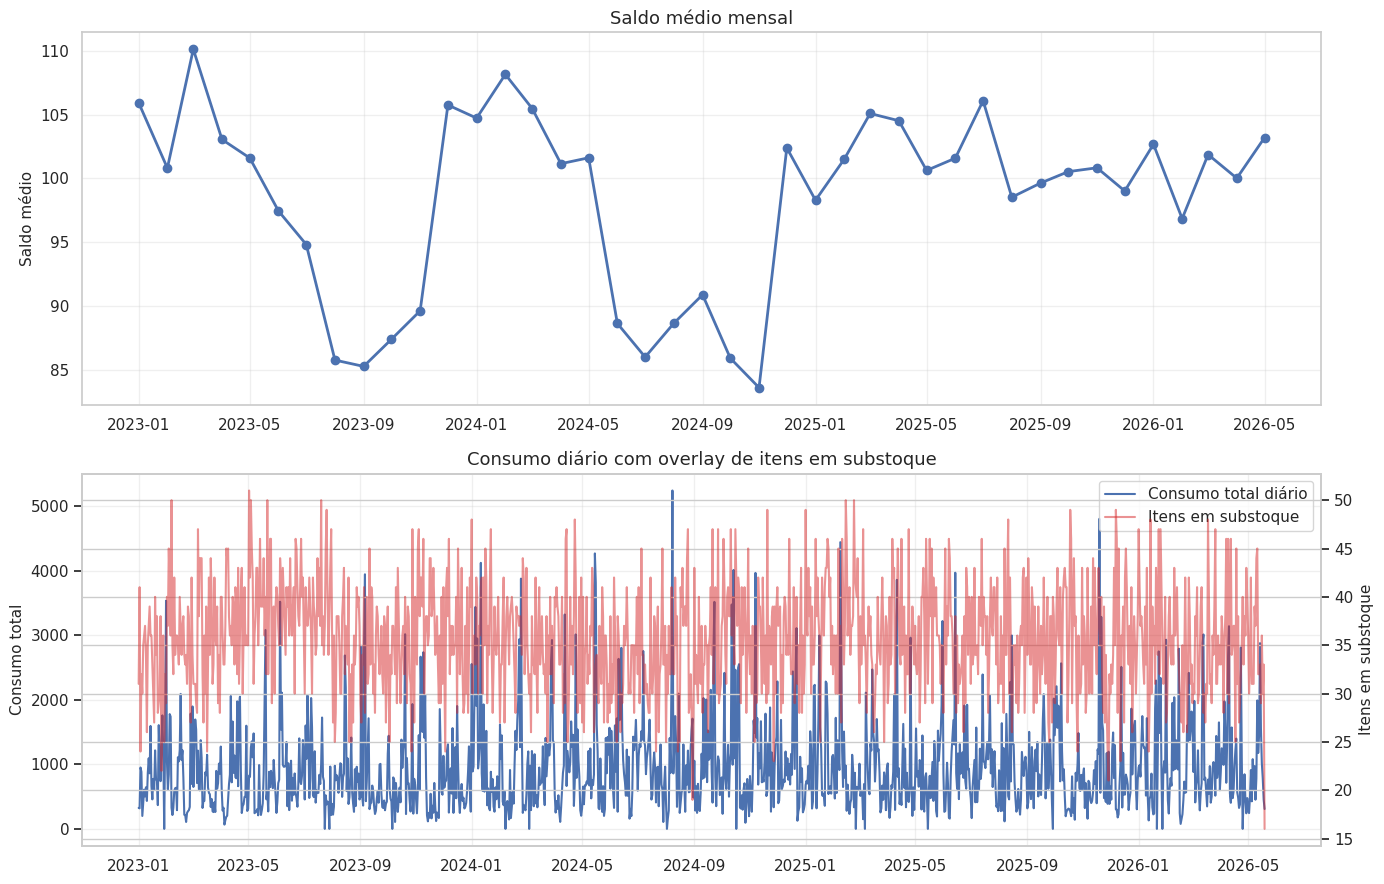

In [3]:
mensal = resumo_mensal.copy()
mensal["periodo"] = pd.to_datetime(
    mensal["year"].astype(str) + "-" + mensal["month"].astype(str).str.zfill(2) + "-01"
)

diario = resumo_diario.sort_values("date").copy()

fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=False)

axes[0].plot(mensal["periodo"], mensal["saldo_medio"], marker="o", linewidth=2)
axes[0].set_title("Saldo médio mensal")
axes[0].set_ylabel("Saldo médio")
axes[0].grid(alpha=0.3)

ax2 = axes[1]
ax2.plot(diario["date"], diario["consumo_total"], label="Consumo total diário", linewidth=1.5)
ax2.set_title("Consumo diário com overlay de itens em substoque")
ax2.set_ylabel("Consumo total")
ax2.grid(alpha=0.3)

ax2b = ax2.twinx()
ax2b.plot(
    diario["date"],
    diario["itens_substoque"],
    color="tab:red",
    alpha=0.5,
    label="Itens em substoque",
)
ax2b.set_ylabel("Itens em substoque")

lines_a, labels_a = ax2.get_legend_handles_labels()
lines_b, labels_b = ax2b.get_legend_handles_labels()
ax2.legend(lines_a + lines_b, labels_a + labels_b, loc="upper right")

plt.tight_layout()
plt.show()

## 4. Sazonalidade semanal e mensal

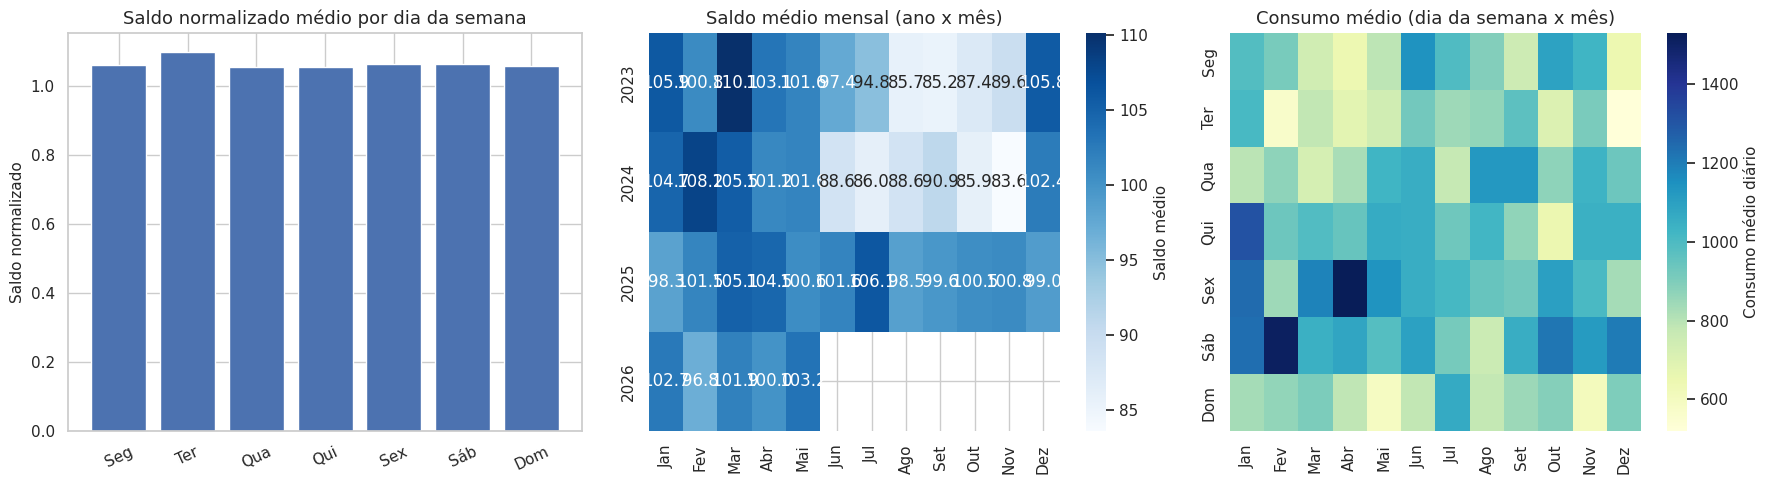

In [4]:
saldo_semana = df.groupby("dia_semana", as_index=False)["saldo_norm"].mean().sort_values("dia_semana")
saldo_semana["dia"] = saldo_semana["dia_semana"].map({i: d for i, d in enumerate(DIAS_PT)})

heat_mensal = resumo_mensal.pivot(index="year", columns="month", values="saldo_medio")
heat_mensal = heat_mensal.reindex(columns=sorted(heat_mensal.columns))
heat_mensal.columns = [MESES_PT[m] for m in heat_mensal.columns]

resumo_tmp = resumo_diario.copy()
resumo_tmp["mes"] = resumo_tmp["date"].dt.month
resumo_tmp["dia_semana"] = resumo_tmp["date"].dt.weekday
heat_semana_mes = resumo_tmp.pivot_table(
    index="dia_semana", columns="mes", values="consumo_total", aggfunc="mean"
).reindex(index=range(7), columns=range(1, 13))
heat_semana_mes.index = DIAS_PT
heat_semana_mes.columns = [MESES_PT[m] for m in heat_semana_mes.columns]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].bar(saldo_semana["dia"], saldo_semana["saldo_norm"], color=sns.color_palette("deep")[0])
axes[0].set_title("Saldo normalizado médio por dia da semana")
axes[0].set_ylabel("Saldo normalizado")
axes[0].tick_params(axis="x", rotation=25)

sns.heatmap(heat_mensal, cmap="Blues", annot=True, fmt=".1f", ax=axes[1], cbar_kws={"label": "Saldo médio"})
axes[1].set_title("Saldo médio mensal (ano x mês)")
axes[1].set_xlabel("")
axes[1].set_ylabel("")

sns.heatmap(heat_semana_mes, cmap="YlGnBu", ax=axes[2], cbar_kws={"label": "Consumo médio diário"})
axes[2].set_title("Consumo médio (dia da semana x mês)")
axes[2].set_xlabel("")
axes[2].set_ylabel("")

plt.tight_layout()
plt.show()

## 5. Distribuição por categoria

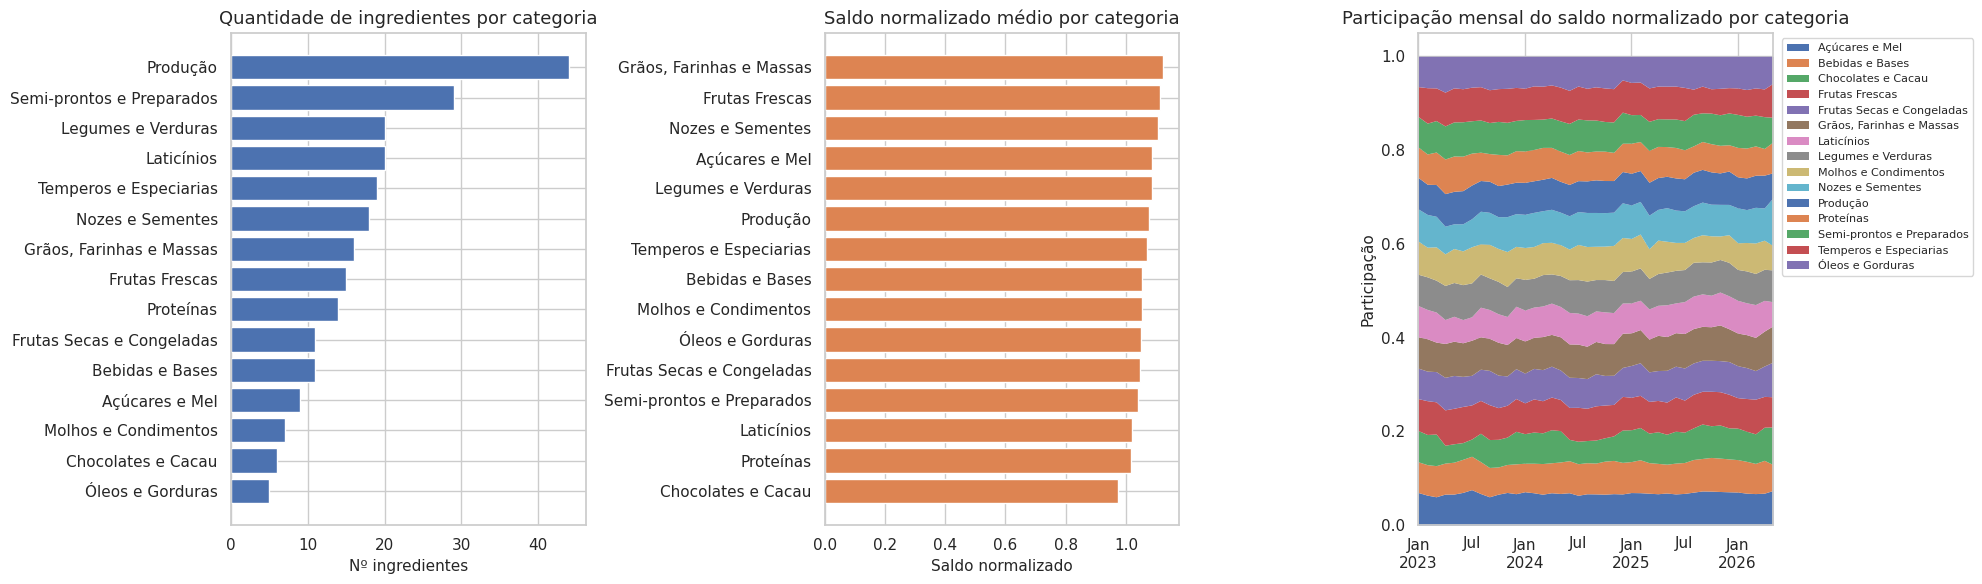

In [5]:
cat_counts = df[["ingredient_id", "categoria"]].drop_duplicates().groupby("categoria")["ingredient_id"].count().sort_values(ascending=True)
cat_norm = df.groupby("categoria", as_index=False)["saldo_norm"].mean().sort_values("saldo_norm", ascending=True)

cat_month = (
    df.groupby(["ano", "mes", "categoria"], as_index=False)["saldo_norm"]
    .mean()
)
cat_month["periodo"] = pd.to_datetime(cat_month["ano"].astype(str) + "-" + cat_month["mes"].astype(str).str.zfill(2) + "-01")
cat_pivot = cat_month.pivot(index="periodo", columns="categoria", values="saldo_norm").fillna(0)
share = cat_pivot.div(cat_pivot.sum(axis=1).replace(0, np.nan), axis=0).fillna(0)

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
axes[0].barh(cat_counts.index, cat_counts.values, color=sns.color_palette("deep")[0])
axes[0].set_title("Quantidade de ingredientes por categoria")
axes[0].set_xlabel("Nº ingredientes")

axes[1].barh(cat_norm["categoria"], cat_norm["saldo_norm"], color=sns.color_palette("deep")[1])
axes[1].set_title("Saldo normalizado médio por categoria")
axes[1].set_xlabel("Saldo normalizado")

share.plot.area(ax=axes[2], linewidth=0)
axes[2].set_title("Participação mensal do saldo normalizado por categoria")
axes[2].set_ylabel("Participação")
axes[2].set_xlabel("")
axes[2].legend(loc="upper left", bbox_to_anchor=(1.01, 1), fontsize=8)

plt.tight_layout()
plt.show()

## 6. Top ingredientes — saldo e cobertura

/tmp/ipykernel_1082448/2986990373.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_saldo, y="ingrediente", x="saldo_medio", ax=axes[0, 0], palette="Blues_r")
/tmp/ipykernel_1082448/2986990373.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=maior_cov, y="ingrediente", x="cobertura_dias", ax=axes[0, 1], palette="Greens_r")
/tmp/ipykernel_1082448/2986990373.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=menor_cov, y="ingrediente", x="cobertura_dias", ax=axes[1, 0], palette="Oranges_r")


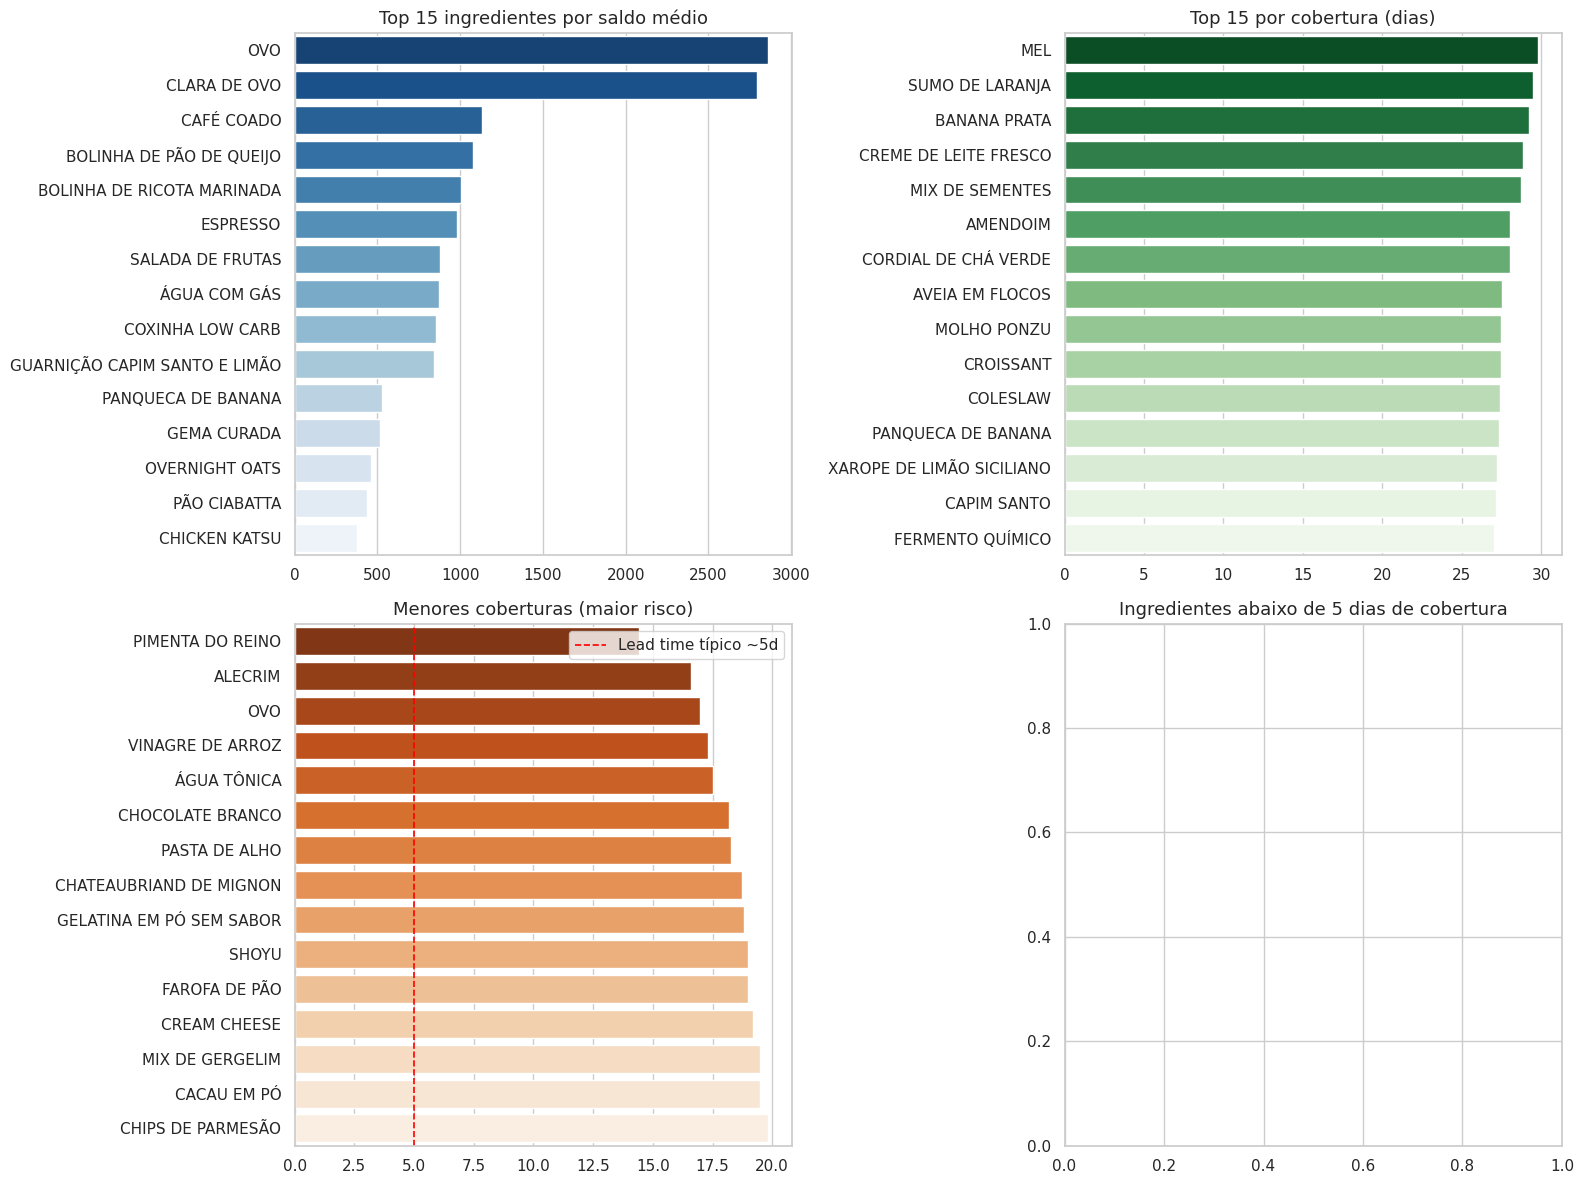

,ingredient_id,ingrediente,unit,cobertura_dias
233,ING0234,PIMENTA DO REINO,KG,14.403111
220,ING0221,ALECRIM,KG,16.612515
162,ING0163,OVO,UND,16.980808
127,ING0128,VINAGRE DE ARROZ,KG,17.324473
24,ING0025,ÁGUA TÔNICA,L,17.500695
29,ING0030,CHOCOLATE BRANCO,KG,18.207276
229,ING0230,PASTA DE ALHO,KG,18.281703
156,ING0157,CHATEAUBRIAND DE MIGNON,KG,18.728761
194,ING0195,GELATINA EM PÓ SEM SABOR,KG,18.802627
125,ING0126,SHOYU,L,18.982550


In [6]:
# Consumo derivado (BOM nível 1)
ri_qty = ri.copy()
ri_qty["qty"] = pd.to_numeric(ri_qty["qty"], errors="coerce").fillna(0.0)
finals = receitas[receitas["type"].str.strip().str.upper() == "PRODUTO_FINAL"].copy()
finals["yield_qty"] = pd.to_numeric(finals["yield_qty"], errors="coerce").fillna(1.0).clip(lower=1.0)

bom = ri_qty.merge(finals[["id", "yield_qty"]], left_on="recipe_id", right_on="id", how="inner")
bom["qty_per_unit"] = bom["qty"] / bom["yield_qty"]

v = vendas.copy()
v["data"] = v["date_time"].dt.floor("D")
cons = v.merge(bom[["recipe_id", "ingredient_id", "qty_per_unit"]], on="recipe_id", how="inner")
cons["consumo"] = cons["quantity"] * cons["qty_per_unit"]
consumo_diario = cons.groupby(["data", "ingredient_id"], as_index=False)["consumo"].sum()
consumo_medio = consumo_diario.groupby("ingredient_id", as_index=False)["consumo"].mean().rename(columns={"consumo": "consumo_diario_medio"})

saldo_medio = (
    df.groupby(["ingredient_id", "ingrediente", "unit", "categoria"], as_index=False)["quantity"]
    .mean()
    .rename(columns={"quantity": "saldo_medio"})
)

top_df = saldo_medio.merge(consumo_medio, on="ingredient_id", how="left")
top_df["consumo_diario_medio"] = top_df["consumo_diario_medio"].fillna(0)
top_df["cobertura_dias"] = np.where(top_df["consumo_diario_medio"] > 0, top_df["saldo_medio"] / top_df["consumo_diario_medio"], np.nan)

top_saldo = top_df.nlargest(15, "saldo_medio")
valid_cov = top_df[top_df["cobertura_dias"].notna() & np.isfinite(top_df["cobertura_dias"])].copy()
maior_cov = valid_cov.nlargest(15, "cobertura_dias")
menor_cov = valid_cov.nsmallest(15, "cobertura_dias")
menor_cov_risco = menor_cov[menor_cov["cobertura_dias"] < 5]

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

sns.barplot(data=top_saldo, y="ingrediente", x="saldo_medio", ax=axes[0, 0], palette="Blues_r")
axes[0, 0].set_title("Top 15 ingredientes por saldo médio")

sns.barplot(data=maior_cov, y="ingrediente", x="cobertura_dias", ax=axes[0, 1], palette="Greens_r")
axes[0, 1].set_title("Top 15 por cobertura (dias)")

sns.barplot(data=menor_cov, y="ingrediente", x="cobertura_dias", ax=axes[1, 0], palette="Oranges_r")
axes[1, 0].set_title("Menores coberturas (maior risco)")
axes[1, 0].axvline(5, color="red", linestyle="--", linewidth=1.2, label="Lead time típico ~5d")
axes[1, 0].legend()

sns.barplot(data=menor_cov_risco.head(15), y="ingrediente", x="cobertura_dias", ax=axes[1, 1], palette="Reds_r")
axes[1, 1].set_title("Ingredientes abaixo de 5 dias de cobertura")

for ax in axes.ravel():
    ax.set_xlabel("")
    ax.set_ylabel("")

plt.tight_layout()
plt.show()

menor_cov[["ingredient_id", "ingrediente", "unit", "cobertura_dias"]].head(10)

## 7. Sobrestoque, substoque e ruptura

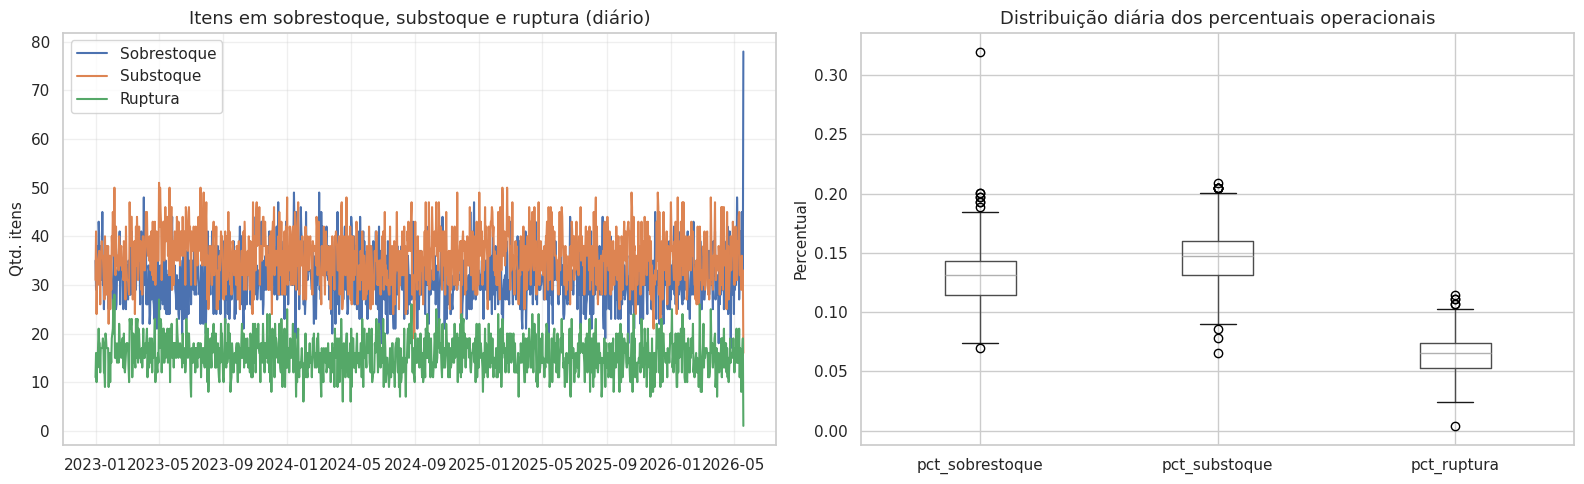

,ingredient_id,ingrediente,unit,ruptura
167,ING0168,APARAS DE PÃO,KG,27.4%
175,ING0176,BLONDIE,UND,27.2%
84,ING0085,IOGURTE GREGO,L,26.6%
179,ING0180,BROWNIE,UND,26.6%
57,ING0058,UVA PASSA BRANCA,KG,19.8%
67,ING0068,FERMENTO BIOLÓGICO SECO,KG,19.8%
15,ING0016,ESSÊNCIA DE BAUNILHA,L,19.6%
71,ING0072,MASSA PARA PASTEL,KG,19.5%
4,ING0005,AÇÚCAR IMPALPÁVEL,KG,19.5%
0,ING0001,AÇÚCAR CRISTAL,KG,19.5%


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

rd = resumo_diario.sort_values("date").copy()
axes[0].plot(rd["date"], rd["itens_sobrestoque"], label="Sobrestoque")
axes[0].plot(rd["date"], rd["itens_substoque"], label="Substoque")
axes[0].plot(rd["date"], rd["itens_ruptura"], label="Ruptura")
axes[0].set_title("Itens em sobrestoque, substoque e ruptura (diário)")
axes[0].set_ylabel("Qtd. itens")
axes[0].legend()
axes[0].grid(alpha=0.3)

n_ings = df["ingredient_id"].nunique()
status_pct = pd.DataFrame(
    {
        "pct_sobrestoque": rd["itens_sobrestoque"] / n_ings,
        "pct_substoque": rd["itens_substoque"] / n_ings,
        "pct_ruptura": rd["itens_ruptura"] / n_ings,
    }
)
status_pct.boxplot(ax=axes[1])
axes[1].set_title("Distribuição diária dos percentuais operacionais")
axes[1].set_ylabel("Percentual")

plt.tight_layout()
plt.show()

# Top 10 ingredientes por % de dias em ruptura
rupt = (
    df.assign(ruptura=(df["quantity"] <= 1e-9).astype(int))
    .groupby(["ingredient_id", "ingrediente", "unit"], as_index=False)["ruptura"]
    .mean()
    .sort_values("ruptura", ascending=False)
    .head(10)
)
rupt["ruptura"] = (rupt["ruptura"] * 100).round(1).astype(str) + "%"
rupt

## 8. Impacto da indisponibilidade de produto

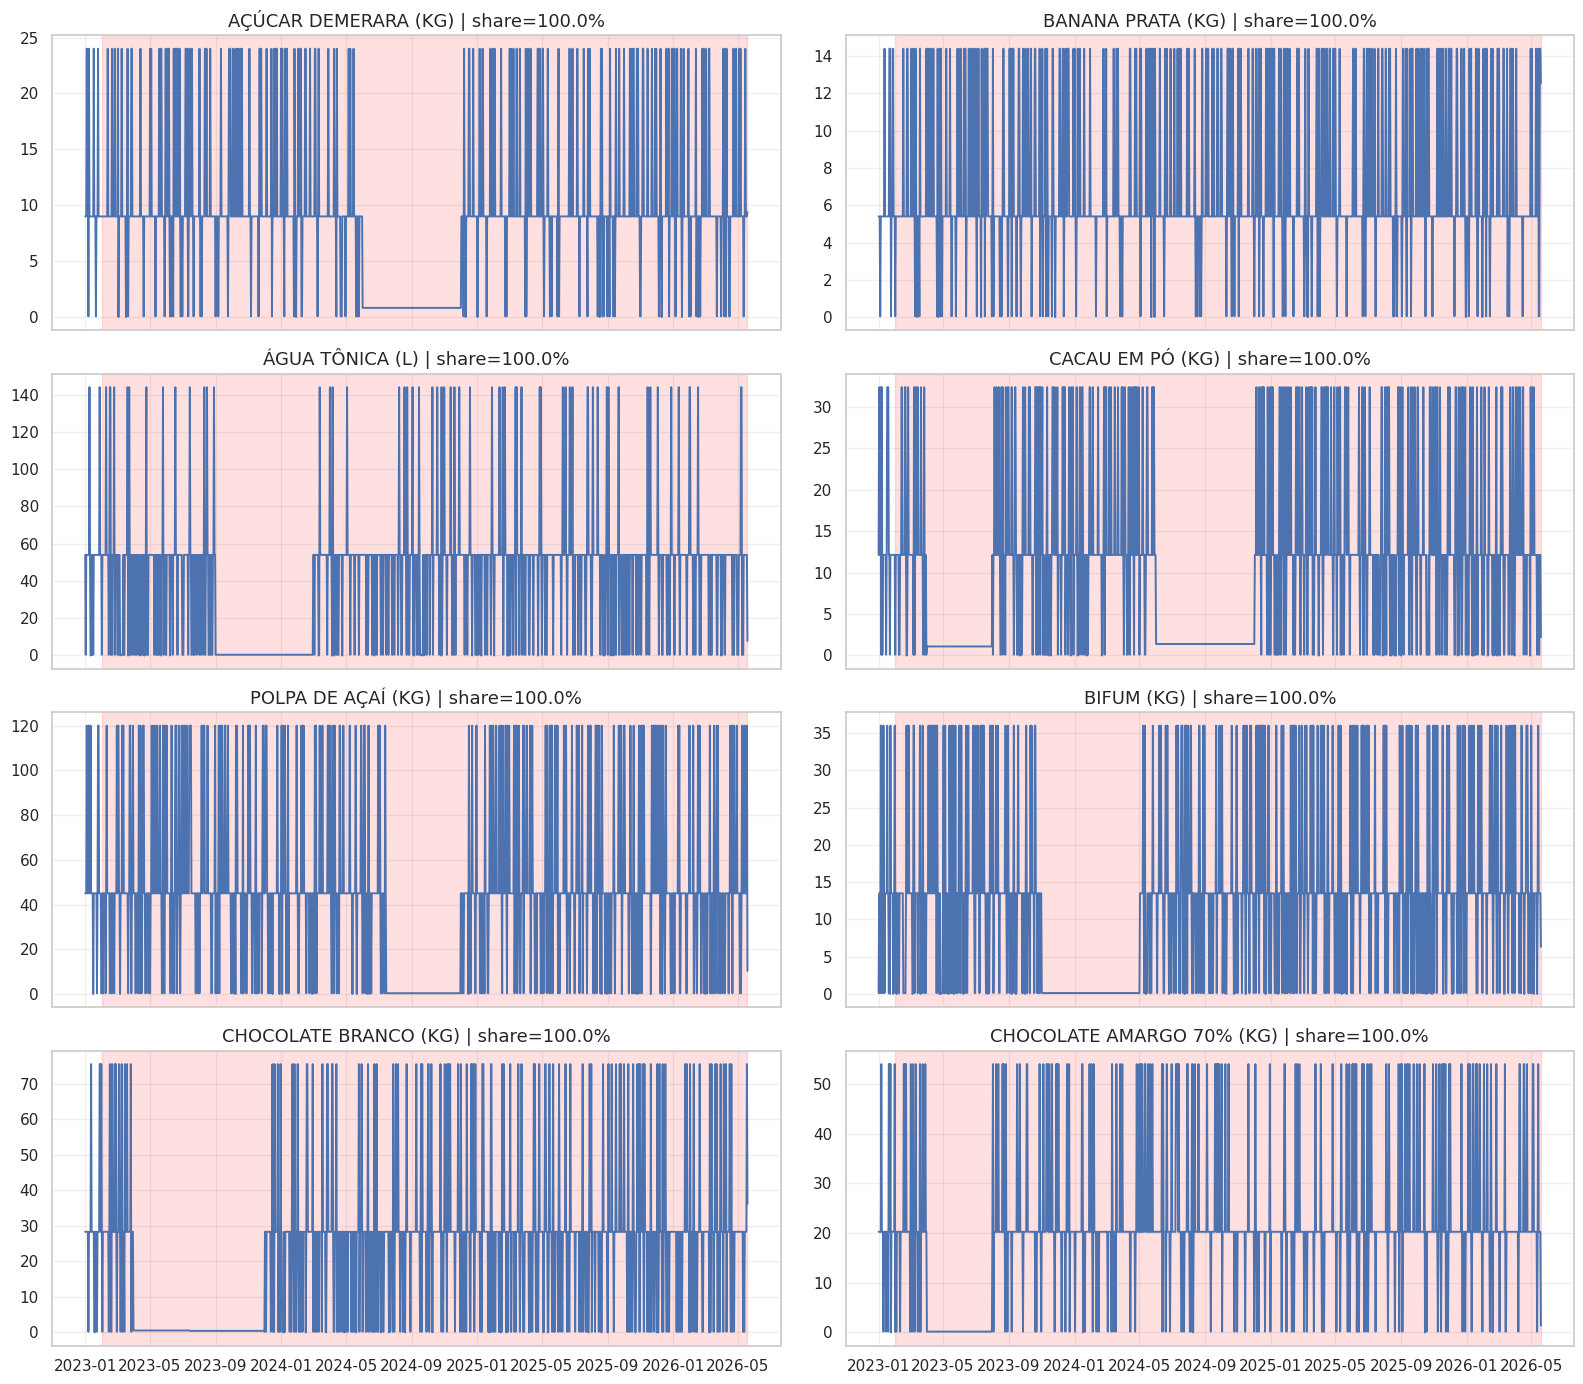

In [8]:
finals = receitas[receitas["type"].str.strip().str.upper() == "PRODUTO_FINAL"].copy()
finals["id"] = finals["id"].astype(str)
finals["name_u"] = finals["name"].astype(str).str.upper()

# Resolve recipe_ids indisponíveis via match em id ou substring de nome
paused_ids = set()
for _, row in indisp.iterrows():
    token = str(row["match"]).strip()
    if not token:
        continue
    if token in set(finals["id"]):
        paused_ids.add(token)
    else:
        mask = finals["name_u"].str.contains(token.upper(), na=False, regex=False)
        paused_ids.update(finals.loc[mask, "id"].tolist())

ri_qty = ri.copy()
ri_qty["qty"] = pd.to_numeric(ri_qty["qty"], errors="coerce").fillna(0.0)

# BOM nível 1
finals_tmp = finals.copy()
finals_tmp["yield_qty"] = pd.to_numeric(finals_tmp["yield_qty"], errors="coerce").fillna(1.0).clip(lower=1.0)
bom1 = ri_qty.merge(finals_tmp[["id", "yield_qty"]], left_on="recipe_id", right_on="id", how="inner")
bom1["qty_per_unit"] = bom1["qty"] / bom1["yield_qty"]

# BOM nível 2 via semi-acabados
prod = receitas[receitas["type"].str.strip().str.upper() == "PRODUCAO"].copy()
prod = prod.dropna(subset=["output_ingredient_id"]).copy()
prod["output_ingredient_id"] = prod["output_ingredient_id"].astype(str)
prod["yield_qty"] = pd.to_numeric(prod["yield_qty"], errors="coerce").fillna(1.0).clip(lower=1.0)

prod_bom = ri_qty.merge(prod[["id", "yield_qty", "output_ingredient_id"]], left_on="recipe_id", right_on="id", how="inner")
prod_bom["qty_per_yield"] = prod_bom["qty"] / prod_bom["yield_qty"]

semi_lookup = {}
for out_id, grp in prod_bom.groupby("output_ingredient_id"):
    semi_lookup[out_id] = [(str(r["ingredient_id"]), float(r["qty_per_yield"])) for _, r in grp.iterrows()]

# Share de impacto por ingrediente
sales_total = vendas.groupby("recipe_id", as_index=False)["quantity"].sum()
base = bom1[["recipe_id", "ingredient_id", "qty_per_unit"]].copy()
base["recipe_id"] = base["recipe_id"].astype(str)
base["ingredient_id"] = base["ingredient_id"].astype(str)

direct_total = sales_total.merge(base, on="recipe_id", how="inner")
direct_total["cons"] = direct_total["quantity"] * direct_total["qty_per_unit"]
total_by_ing = direct_total.groupby("ingredient_id", as_index=False)["cons"].sum().rename(columns={"cons": "total"})

paused_sales = sales_total[sales_total["recipe_id"].astype(str).isin(paused_ids)].copy()
paused_direct = paused_sales.merge(base, on="recipe_id", how="inner")
paused_direct["cons"] = paused_direct["quantity"] * paused_direct["qty_per_unit"]
paused_by_ing = paused_direct.groupby("ingredient_id", as_index=False)["cons"].sum().rename(columns={"cons": "paused"})

impact = total_by_ing.merge(paused_by_ing, on="ingredient_id", how="left")
impact["paused"] = impact["paused"].fillna(0)
impact["share"] = np.where(impact["total"] > 0, impact["paused"] / impact["total"], 0)

# Expansão para folhas quando ingrediente direto é semi-acabado
for semi_id, leaves in semi_lookup.items():
    share_semi = float(impact.loc[impact["ingredient_id"] == semi_id, "share"].max()) if (impact["ingredient_id"] == semi_id).any() else 0.0
    if share_semi <= 0:
        continue
    for leaf_id, _ in leaves:
        idx = impact[impact["ingredient_id"] == leaf_id].index
        if len(idx):
            impact.loc[idx, "share"] = np.maximum(impact.loc[idx, "share"], share_semi * 0.85)

impact = impact.merge(df[["ingredient_id", "ingrediente", "unit"]].drop_duplicates(), on="ingredient_id", how="left")
impact = impact.sort_values("share", ascending=False)

if indisp.empty:
    print("Nenhum período de indisponibilidade informado.")
else:
    jan_ini = indisp["data_inicio"].min()
    jan_fim = indisp["data_fim"].max()
    top_imp = impact[impact["share"] > 0].head(8)

    fig, axes = plt.subplots(4, 2, figsize=(16, 14), sharex=True)
    axes = axes.ravel()

    for i, (_, row) in enumerate(top_imp.iterrows()):
        sub = (
            df[df["ingredient_id"] == row["ingredient_id"]]
            .groupby("data", as_index=False)["quantity"]
            .mean()
            .sort_values("data")
        )
        axes[i].plot(sub["data"], sub["quantity"], linewidth=1.4)
        axes[i].axvspan(jan_ini, jan_fim, color="red", alpha=0.12)
        axes[i].set_title(f"{row['ingrediente']} ({row['unit']}) | share={row['share']:.1%}")
        axes[i].grid(alpha=0.3)

    for j in range(len(top_imp), len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    plt.show()

    comparativo = []
    top15 = impact[impact["share"] > 0].head(15)
    for _, row in top15.iterrows():
        sub = df[df["ingredient_id"] == row["ingredient_id"]][["data", "quantity"]]
        dentro = sub[(sub["data"] >= jan_ini) & (sub["data"] <= jan_fim)]["quantity"].mean()
        fora = sub[(sub["data"] < jan_ini) | (sub["data"] > jan_fim)]["quantity"].mean()
        delta = ((dentro / fora) - 1) * 100 if pd.notna(fora) and fora > 0 else np.nan
        comparativo.append(
            {
                "ingredient_id": row["ingredient_id"],
                "ingrediente": row["ingrediente"],
                "share": row["share"],
                "saldo_medio_dentro_janela": dentro,
                "saldo_medio_fora_janela": fora,
                "delta_%": delta,
            }
        )

    comp_df = pd.DataFrame(comparativo).sort_values("share", ascending=False)
    comp_df

## 9. Coerência consumo x estoque

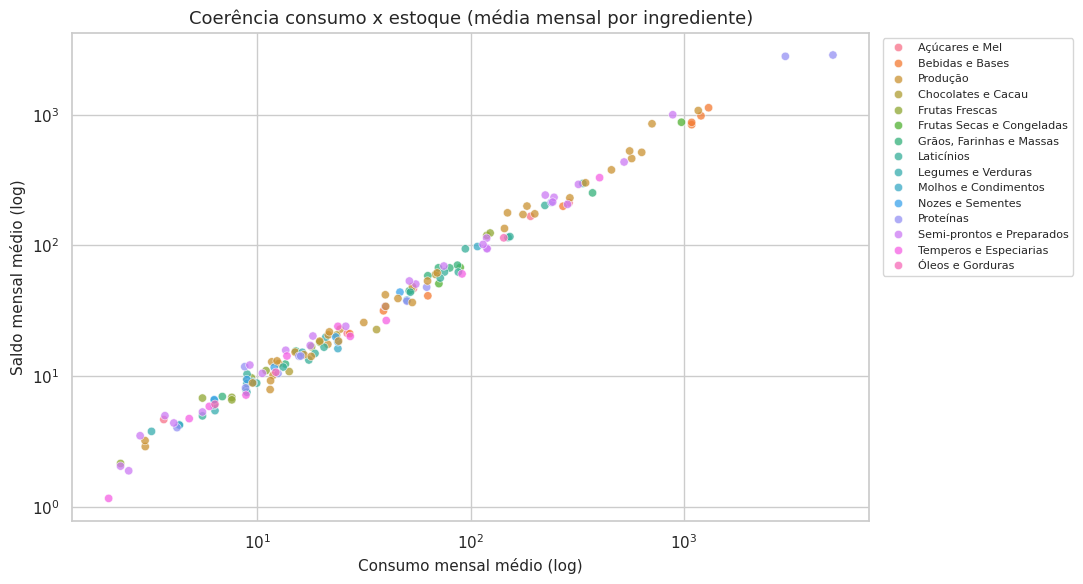

Correlação Spearman: 0.995
Correlação Pearson: 0.969


,ingredient_id,categoria,saldo_mensal_medio,consumo_mensal_medio
104,ING0163,Proteínas,2867.455629,4997.195122
100,ING0159,Proteínas,2800.998701,2989.829268
6,ING0010,Bebidas e Bases,1132.277121,1305.780488
10,ING0015,Bebidas e Bases,982.101032,1202.963415
117,ING0177,Produção,1077.346647,1168.048780
16,ING0023,Bebidas e Bases,874.664579,1087.731707
12,ING0019,Bebidas e Bases,839.777645,1087.731707
38,ING0057,Frutas Secas e Congeladas,877.237094,974.121951
118,ING0178,Semi-prontos e Preparados,1000.786017,886.707317
125,ING0185,Produção,853.479110,708.902439


In [9]:
cons["ano"] = cons["date_time"].dt.year
cons["mes"] = cons["date_time"].dt.month
cons_mensal = cons.groupby(["ano", "mes", "ingredient_id"], as_index=False)["consumo"].sum()
cons_mensal_tot = cons_mensal.groupby("ingredient_id", as_index=False)["consumo"].mean().rename(columns={"consumo": "consumo_mensal_medio"})

saldo_mensal = (
    df.groupby(["ano", "mes", "ingredient_id", "categoria"], as_index=False)["quantity"]
    .mean()
)
saldo_mensal_tot = saldo_mensal.groupby(["ingredient_id", "categoria"], as_index=False)["quantity"].mean().rename(columns={"quantity": "saldo_mensal_medio"})

coer = saldo_mensal_tot.merge(cons_mensal_tot, on="ingredient_id", how="inner")
coer = coer[(coer["consumo_mensal_medio"] > 0) & (coer["saldo_mensal_medio"] > 0)].copy()

fig, ax = plt.subplots(figsize=(11, 6))
sns.scatterplot(
    data=coer,
    x="consumo_mensal_medio",
    y="saldo_mensal_medio",
    hue="categoria",
    alpha=0.75,
    ax=ax,
)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_title("Coerência consumo x estoque (média mensal por ingrediente)")
ax.set_xlabel("Consumo mensal médio (log)")
ax.set_ylabel("Saldo mensal médio (log)")
ax.legend(loc="upper left", bbox_to_anchor=(1.01, 1), fontsize=8)
plt.tight_layout()
plt.show()

spearman = coer["consumo_mensal_medio"].rank().corr(coer["saldo_mensal_medio"].rank())
pearson = coer["consumo_mensal_medio"].corr(coer["saldo_mensal_medio"])
print(f"Correlação Spearman: {spearman:.3f}")
print(f"Correlação Pearson: {pearson:.3f}")
coer.sort_values("consumo_mensal_medio", ascending=False).head(10)

## 10. Pedidos a fornecedores

A operação faz pedidos preferencialmente às **sextas-feiras**. Pedidos em outros dias são exceções
(ruptura iminente). Os blocos abaixo validam essa cadência, distribuição por fornecedor e o valor
mensal de compras.

In [10]:
if pedidos.empty:
    print("pedidos.csv não encontrado — execute data/Scripts/gerar_pedidos.py.")
else:
    ped = pedidos.copy()
    ped["dia_semana"] = ped["data_pedido"].dt.weekday
    ped["ano"] = ped["data_pedido"].dt.year
    ped["mes"] = ped["data_pedido"].dt.month
    ped["lead_dias"] = (ped["data_prevista"] - ped["data_pedido"]).dt.days
    is_sexta = ped["dia_semana"] == 4

    kpi_ped = pd.DataFrame(
        {
            "Métrica": [
                "Total de pedidos",
                "Pedidos na sexta (rotina)",
                "Pedidos em outros dias (exceção)",
                "% na sexta-feira",
                "Fornecedores únicos",
                "Ingredientes únicos",
                "Valor total (R$)",
                "Ticket médio (R$/pedido)",
                "Lead time médio (dias)",
                "Pedidos em trânsito",
            ],
            "Valor": [
                f"{len(ped):,}",
                f"{int(is_sexta.sum()):,}",
                f"{int((~is_sexta).sum()):,}",
                f"{is_sexta.mean():.1%}",
                f"{ped['supplier_id'].nunique():,}",
                f"{ped['ingredient_id'].nunique():,}",
                f"R$ {ped['valor'].sum():,.2f}",
                f"R$ {ped['valor'].mean():,.2f}",
                f"{ped['lead_dias'].mean():.1f}",
                f"{int((ped['status'] == 'em_transito').sum()):,}",
            ],
        }
    )
    display(kpi_ped)

,Métrica,Valor
0,Total de pedidos,"15,647"
1,Pedidos na sexta (rotina),"10,321"
2,Pedidos em outros dias (exceção),"5,326"
3,% na sexta-feira,66.0%
4,Fornecedores únicos,24
5,Ingredientes únicos,200
6,Valor total (R$),"R$ 8,560,837.86"
7,Ticket médio (R$/pedido),R$ 547.12
8,Lead time médio (dias),3.4
9,Pedidos em trânsito,11


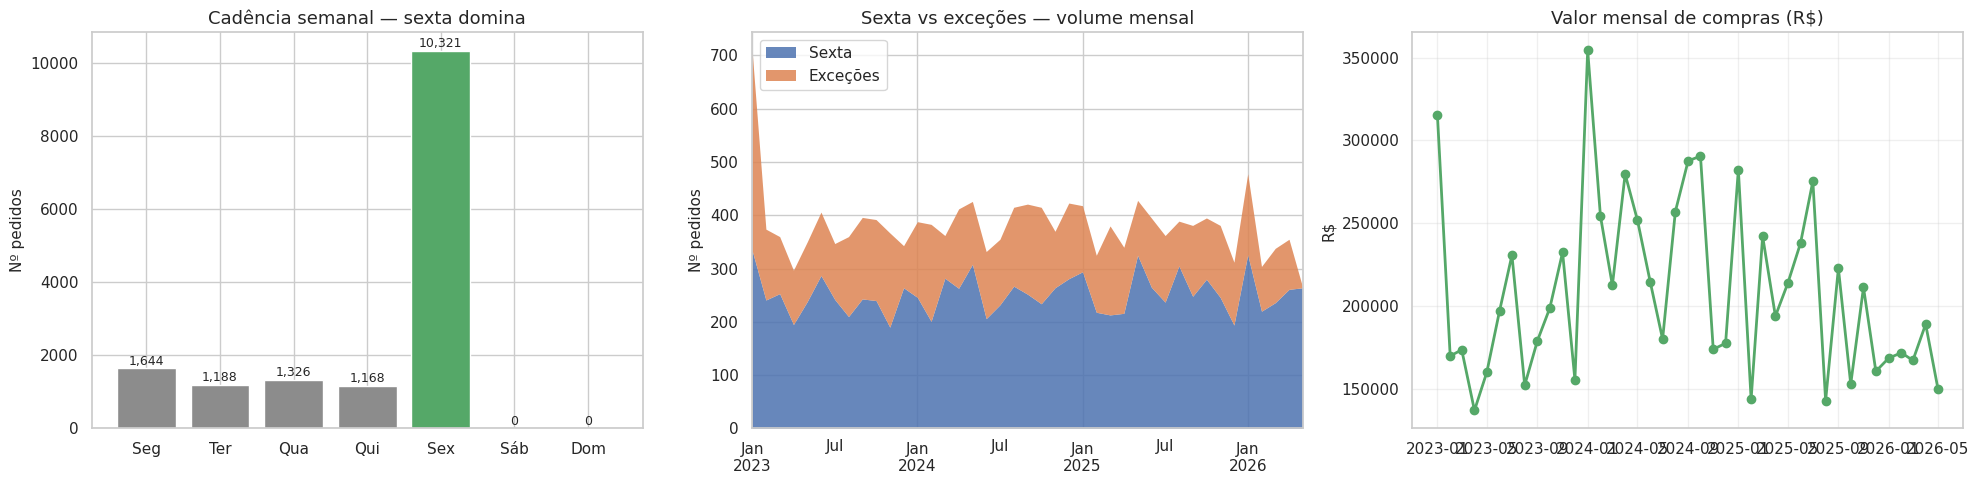

In [11]:
if not pedidos.empty:
    por_dow = ped.groupby("dia_semana").size().reindex(range(7), fill_value=0)
    por_dow.index = DIAS_PT

    mensal_ped = (
        ped.assign(periodo=ped["data_pedido"].dt.to_period("M").dt.to_timestamp())
        .groupby(["periodo", ped["dia_semana"].eq(4).map({True: "Sexta", False: "Exceções"})])
        .size()
        .unstack(fill_value=0)
    )
    if "Sexta" not in mensal_ped.columns:
        mensal_ped["Sexta"] = 0
    if "Exceções" not in mensal_ped.columns:
        mensal_ped["Exceções"] = 0
    mensal_ped = mensal_ped[["Sexta", "Exceções"]]

    valor_mensal = (
        ped.assign(periodo=ped["data_pedido"].dt.to_period("M").dt.to_timestamp())
        .groupby("periodo", as_index=False)["valor"]
        .sum()
    )

    fig, axes = plt.subplots(1, 3, figsize=(20, 5))

    cores_dow = [sns.color_palette("deep")[7]] * 7
    cores_dow[4] = sns.color_palette("deep")[2]  # destaque sexta
    axes[0].bar(por_dow.index, por_dow.values, color=cores_dow, edgecolor="white")
    axes[0].set_title("Cadência semanal — sexta domina")
    axes[0].set_ylabel("Nº pedidos")
    for i, v in enumerate(por_dow.values):
        axes[0].text(i, v + max(por_dow.values) * 0.01, f"{int(v):,}", ha="center", fontsize=9)

    mensal_ped.plot.area(ax=axes[1], color=["#4C72B0", "#DD8452"], alpha=0.85, linewidth=0)
    axes[1].set_title("Sexta vs exceções — volume mensal")
    axes[1].set_ylabel("Nº pedidos")
    axes[1].set_xlabel("")
    axes[1].legend(loc="upper left")

    axes[2].plot(valor_mensal["periodo"], valor_mensal["valor"], marker="o", color="#55A868", linewidth=2)
    axes[2].set_title("Valor mensal de compras (R$)")
    axes[2].set_ylabel("R$")
    axes[2].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

/tmp/ipykernel_1082448/1947563026.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_for_qtd.reset_index(), y="nome", x="pedidos", ax=axes[0], palette="Blues_r")
/tmp/ipykernel_1082448/1947563026.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_for_valor.reset_index(), y="nome", x="valor", ax=axes[1], palette="Greens_r")


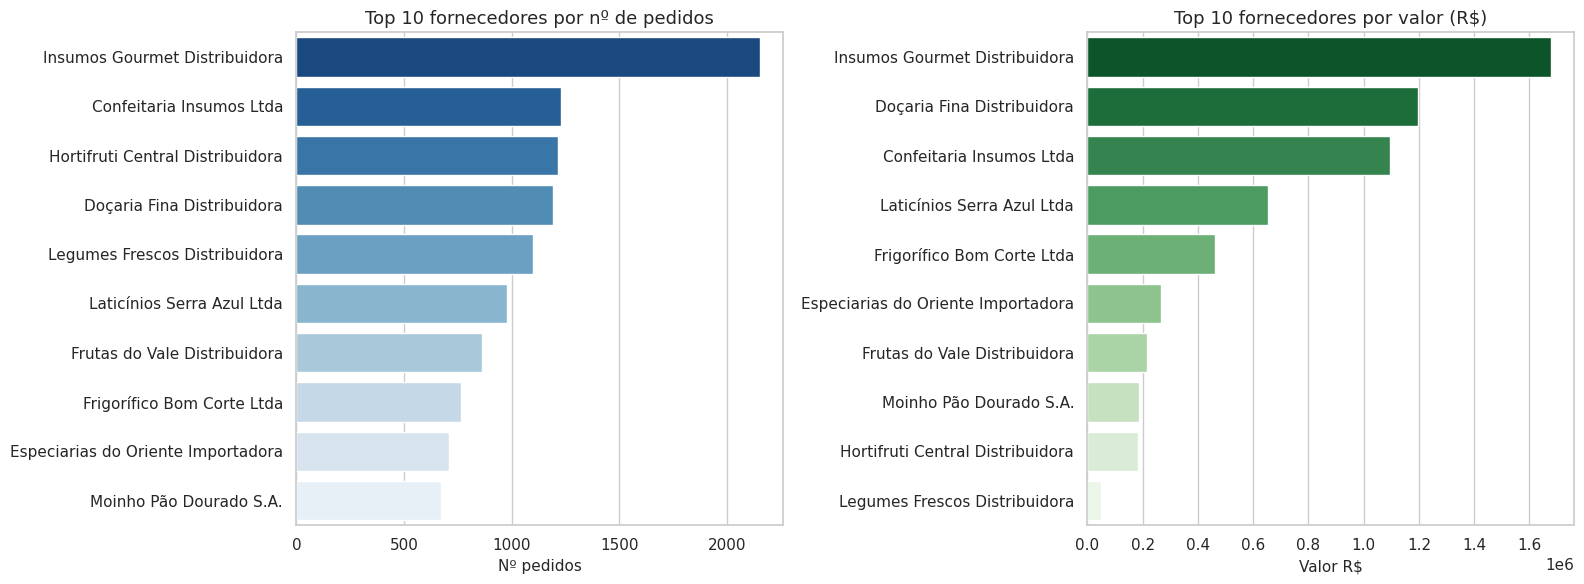

In [12]:
if not pedidos.empty:
    fornec_path = DATA_DIR / "fornecedores.csv"
    fornec = pd.read_csv(fornec_path) if fornec_path.exists() else None

    top_for_qtd = (
        ped.groupby("supplier_id")
        .agg(pedidos=("id", "count"), valor=("valor", "sum"))
        .sort_values("pedidos", ascending=False)
        .head(10)
    )
    top_for_valor = top_for_qtd.sort_values("valor", ascending=False).head(10)

    if fornec is not None:
        name_map = dict(zip(fornec["id"].astype(str), fornec["name"].astype(str)))
        top_for_qtd["nome"] = top_for_qtd.index.map(lambda i: name_map.get(i, i)[:35])
        top_for_valor["nome"] = top_for_valor.index.map(lambda i: name_map.get(i, i)[:35])
    else:
        top_for_qtd["nome"] = top_for_qtd.index
        top_for_valor["nome"] = top_for_valor.index

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    sns.barplot(data=top_for_qtd.reset_index(), y="nome", x="pedidos", ax=axes[0], palette="Blues_r")
    axes[0].set_title("Top 10 fornecedores por nº de pedidos")
    axes[0].set_xlabel("Nº pedidos")
    axes[0].set_ylabel("")

    sns.barplot(data=top_for_valor.reset_index(), y="nome", x="valor", ax=axes[1], palette="Greens_r")
    axes[1].set_title("Top 10 fornecedores por valor (R$)")
    axes[1].set_xlabel("Valor R$")
    axes[1].set_ylabel("")

    plt.tight_layout()
    plt.show()